# Forecasting _**Magic: The Gathering**_ Card Price from Card Features

<div style="display: flex; justify-content: center; gap: 20px;">
    <img src="C:\Users\ellie\Desktop\sample_folder_1\rusko.jpg" width="300">
    <img src="C:\Users\ellie\Desktop\sample_folder_1\mtgback.webp" width="300">
    <img src="C:\Users\ellie\Desktop\sample_folder_1\jodah.jpg" width="300">
</div>

**Magic: The Gathering (MTG)** is a strategic trading card game where players act as powerful wizards called planeswalkers, building decks of spells, creatures, and magical effects. By playing lands to generate mana, they cast spells and summon creatures to attack opponents and reduce their life total to 0. The game stands out for its deep strategy, vast variety of cards, and flexible play styles, combining creativity and competition in a fantasy setting.

In this project, **Magic: The Gathering** is treated as a structured dataset in which each card is an observation described by features such as rarity, mana cost, color, type, abilities, release set, etc. These characteristics, along with external factors like playability and scarcity, are used to model and predict a continuous outcome, USD card price, framing the TCG as a real-world application of supervised learning and predictive modeling.

## 1. Problem Definition
We want to predict Magic: The Gathering (MTG) card values in USD. For this, we will be using the following packages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import scrython as scry

## 2. Data Exploration and Variable Creation

The first step to look into our data is to download all unique cards at once, then transform them into a pandas dataframe. We will use a Scryfall API to search the Oracle database, which holds the most up-to-date, errata-corrected text for every MTG card.

In [2]:
bulk = scry.bulk_data.ByType(type='oracle_cards') # Use the Oracle database
cards = bulk.download() # Download the cards' characteristics at a given time and store the results 
df = pd.DataFrame(cards) # Transform into pandas dataframe

However, most trading cards are in a specific category of cards. Thus, we'll filter them.

In [3]:
allowed_types = [
    "Land", "Creature", "Artifact", "Enchantment",
    "Planeswalker", "Battle", "Instant", "Sorcery"
]

# Filter out unwanted cards
pattern = "|".join(allowed_types)

df = df[df["type_line"].str.contains(pattern, na=False)]

is_paper = df["games"].apply(lambda x: isinstance(x, list) and "paper" in x) # No digital cards, only paper
not_token = ~df["type_line"].str.contains("Token", na=False) # No token cards
not_emblem = ~df["type_line"].str.contains("Emblem", na=False) # No emblems
not_art = df["set_type"] != "art_series" # No art cards
lang_en = df["lang"] == "en" # English language

df = df[is_paper & not_token & not_emblem & not_art & lang_en]

for t in allowed_types:
    df[t.lower()] = df["type_line"].str.contains(t, na=False).astype(int)

The following table shows a dataframe with Magic: The Gathering unique cards.

In [4]:
df

,object,id,oracle_id,multiverse_ids,mtgo_id,tcgplayer_id,cardmarket_id,name,lang,released_at,...,defense,printed_text,land,creature,artifact,enchantment,planeswalker,battle,instant,sorcery
0,card,a471b306-4941-4e46-a0cb-d92895c16f8a,00037840-6089-42ec-8c5c-281f9f474504,[692174],137223.0,615195.0,807933.0,"Nissa, Worldsoul Speaker",en,2025-02-14,...,NaN,NaN,0,1,0,0,0,0,0,0
2,card,86bf43b1-8d4e-4759-bb2d-0b2e03ba7012,0004ebd0-dfd6-4276-b4a6-de0003e94237,[15862],15870.0,3094.0,3081.0,Static Orb,en,2001-04-11,...,NaN,NaN,0,0,1,0,0,0,0,0
3,card,7050735c-b232-47a6-a342-01795bfd0d46,0006faf6-7a61-426c-9034-579f2cfcfa83,[370780],49283.0,69965.0,262945.0,Sensory Deprivation,en,2013-07-19,...,NaN,NaN,0,0,0,1,0,0,0,0
5,card,e718b21b-46d1-4844-985c-52745657b1ac,0007c283-5b7a-4c00-9ca1-b455c8dff8c3,[470580],77122.0,196536.0,391692.0,Road of Return,en,2019-08-23,...,NaN,NaN,0,0,0,0,0,0,0,1
6,card,036ef8c9-72ac-46ce-af07-83b79d736538,000d5588-5a4c-434e-988d-396632ade42c,[83282],22609.0,12835.0,12551.0,Storm Crow,en,2005-07-29,...,NaN,NaN,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37233,card,d6695fa8-881c-407c-91d9-3ac770372d35,fffa9334-3576-4f70-9605-2ad062cdbc69,[430770],64646.0,136683.0,298834.0,Without Weakness,en,2017-07-14,...,NaN,NaN,0,0,0,0,0,0,1,0
37234,card,4d5edf4f-5695-42fc-9e57-c4faef60fbc3,fffaa634-42a0-4038-b027-24f28754fec7,[571548],101914.0,276869.0,665173.0,Firesong and Sunspeaker,en,2022-07-08,...,NaN,NaN,0,1,0,0,0,0,0,0
37235,card,22a6a5f1-1405-4efb-af3e-e1f58d664e99,fffcb71f-e802-436e-917d-eaa6607ab74f,"[503766, 503767]",87643.0,230214.0,530502.0,"Toralf, God of Fury // Toralf's Hammer",en,2021-02-05,...,NaN,NaN,0,1,1,0,0,0,0,0
37236,card,09f06f55-7918-46c4-80ff-0bf39e091a4a,fffdc2ac-bde4-4e4c-a5bd-0e6c6e49ad91,[430833],64772.0,132234.0,298282.0,"Samut, the Tested",en,2017-07-14,...,NaN,NaN,0,0,0,0,1,0,0,0


Let's see all column names before proceeding with the analysis.

In [5]:
df.columns

Index(['object', 'id', 'oracle_id', 'multiverse_ids', 'mtgo_id',
       'tcgplayer_id', 'cardmarket_id', 'name', 'lang', 'released_at', 'uri',
       'scryfall_uri', 'layout', 'highres_image', 'image_status', 'image_uris',
       'mana_cost', 'cmc', 'type_line', 'oracle_text', 'power', 'toughness',
       'colors', 'color_identity', 'keywords', 'all_parts', 'legalities',
       'games', 'reserved', 'game_changer', 'foil', 'nonfoil', 'finishes',
       'oversized', 'promo', 'reprint', 'variation', 'set_id', 'set',
       'set_name', 'set_type', 'set_uri', 'set_search_uri', 'scryfall_set_uri',
       'rulings_uri', 'prints_search_uri', 'collector_number', 'digital',
       'rarity', 'watermark', 'flavor_text', 'card_back_id', 'artist',
       'artist_ids', 'illustration_id', 'border_color', 'frame',
       'frame_effects', 'security_stamp', 'full_art', 'textless', 'booster',
       'story_spotlight', 'edhrec_rank', 'preview', 'prices', 'related_uris',
       'purchase_uris', 'mtgo_foil_i

We have a bunch of information in the dataset that might not be adequate for our analysis. Let's filter it.

First, we'll split the price dictionary into columns for our data. The aim is to use the USD price for normal and foil cards.

In [6]:
prices_expanded = pd.json_normalize(df["prices"])

df = df.join(prices_expanded).drop(columns=["prices"])

df.columns

Index(['object', 'id', 'oracle_id', 'multiverse_ids', 'mtgo_id',
       'tcgplayer_id', 'cardmarket_id', 'name', 'lang', 'released_at', 'uri',
       'scryfall_uri', 'layout', 'highres_image', 'image_status', 'image_uris',
       'mana_cost', 'cmc', 'type_line', 'oracle_text', 'power', 'toughness',
       'colors', 'color_identity', 'keywords', 'all_parts', 'legalities',
       'games', 'reserved', 'game_changer', 'foil', 'nonfoil', 'finishes',
       'oversized', 'promo', 'reprint', 'variation', 'set_id', 'set',
       'set_name', 'set_type', 'set_uri', 'set_search_uri', 'scryfall_set_uri',
       'rulings_uri', 'prints_search_uri', 'collector_number', 'digital',
       'rarity', 'watermark', 'flavor_text', 'card_back_id', 'artist',
       'artist_ids', 'illustration_id', 'border_color', 'frame',
       'frame_effects', 'security_stamp', 'full_art', 'textless', 'booster',
       'story_spotlight', 'edhrec_rank', 'preview', 'related_uris',
       'purchase_uris', 'mtgo_foil_id', 'penny

In addition, we'll split the legalities dictionary to know when a card is legal for each MTG format.

In [7]:
pd.json_normalize(df["legalities"]).columns # The formats

Index(['standard', 'future', 'historic', 'timeless', 'gladiator', 'pioneer',
       'modern', 'legacy', 'pauper', 'vintage', 'penny', 'commander',
       'oathbreaker', 'standardbrawl', 'brawl', 'alchemy', 'paupercommander',
       'duel', 'oldschool', 'premodern', 'predh'],
      dtype='str')

In [8]:
legalities_expanded = pd.json_normalize(df["legalities"]) # Split

df = df.join(legalities_expanded).drop(columns=["legalities"]) # Join and exclude old variable

cols = legalities_expanded.columns # the format names

df[cols] = df[cols].replace({'not_legal': 0, 'legal': 1, 'banned': -1}) # Change to numeric

Each card has a specific effect or cateogy, such as "Flying", "Trample" or "Zombie", but the encoder can get a card characteristics such as "Land Creature", "Activate Ability".

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

type_words = [
    "land", "creature", "artifact", "enchantment",
    "planeswalker", "battle", "instant", "sorcery"
]

color_words = ["white", "blue", "black", "red", "green", "colorless"]

extra_noise = [
    "card", "player", "target", "ability"
]

custom_stop_words = ENGLISH_STOP_WORDS.union(type_words).union(color_words).union(extra_noise)

vectorizer = TfidfVectorizer(
    max_features=80,      # limit features
    ngram_range=(1,2),  # includes "draw a card", "extra turn"
    min_df=5,
    stop_words=list(custom_stop_words)   # remove common words
)


texts = df["oracle_text"].fillna("")

X_tfidf = vectorizer.fit_transform(texts)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

#Excluding the formats only played online
df_selected = df[[
        "land",
        "creature",
        "artifact",
        "enchantment",
        "planeswalker",
        "battle",
        "instant",
        "sorcery",
        "released_at",
        "usd", 
        "usd_foil",
        "produced_mana",
        "defense",
        "mana_cost",
        "colors",
        "rarity",
        "cmc",
        "power",
        "toughness",
        "frame",
        "reprint",
        "standard",
        "pioneer",
        "modern", 
        "legacy",
        "pauper",
        "vintage",
        "commander",
        "oathbreaker",
        "paupercommander",
        "duel", 
        "oldschool",
        "premodern",
        "predh"
    ]]

df_selected = pd.concat([df_selected.reset_index(drop=True), tfidf_df], axis=1)

df_selected.columns

Index(['land', 'creature', 'artifact', 'enchantment', 'planeswalker', 'battle',
       'instant', 'sorcery', 'released_at', 'usd',
       ...
       'strike', 'tap', 'tapped', 'time', 'token', 'trample', 'turn', 'untap',
       'upkeep', 'value'],
      dtype='str', length=114)

In [10]:
feature_names = vectorizer.get_feature_names_out()

In [11]:
bad_words = set(type_words + color_words + extra_noise + list(["power", "toughness"]))

keep_cols = [i for i, f in enumerate(feature_names) if f not in bad_words]

X_tfidf = X_tfidf[:, keep_cols]

In [12]:
[col for col in vectorizer.get_feature_names_out() if col in type_words]

[]

Let's look at the data types of each column.

In [13]:
df_selected.dtypes

land              int64
creature          int64
artifact          int64
enchantment       int64
planeswalker      int64
                 ...   
trample         float64
turn            float64
untap           float64
upkeep          float64
value           float64
Length: 114, dtype: object

Rarity refers to the distribution of cards in MTG boosters. We can see the rarity of all available cards. A brief explanation is below.

- Common: The most frequent, forming the backbone of booster packs and gameplay, usually featuring simple abilities.
- Uncommon: Less frequent than commons, often providing more specialized abilities and key components for building decks (often called "build-around" cards).
- Rare: Powerful, game-defining, or highly complex cards, frequently sought after for competitive play.
- Mythic Rare: The least common and most powerful/spectacular cards, often featuring planeswalkers or legendary creatures. Introduced in Shards of Alara, they generally appear in roughly 1 of every 8 packs, though special packs can vary this frequency.
- Special Cards: These include tokens, helper cards, or substitute cards.

<Axes: xlabel='rarity'>

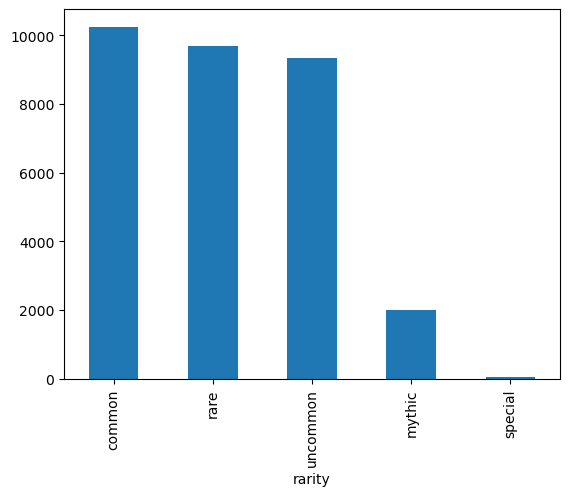

In [14]:
df_selected.rarity.value_counts().plot(kind="bar")

Exploring the data we can see the available colors in MTG below. We have 5 basic colors: White [W], Black [B], Red [R], Green [G] and Blue [U]; in addition to a not-colored card []. Each card can have no color (i.e., []), one or multiple colors.

<Axes: xlabel='colors'>

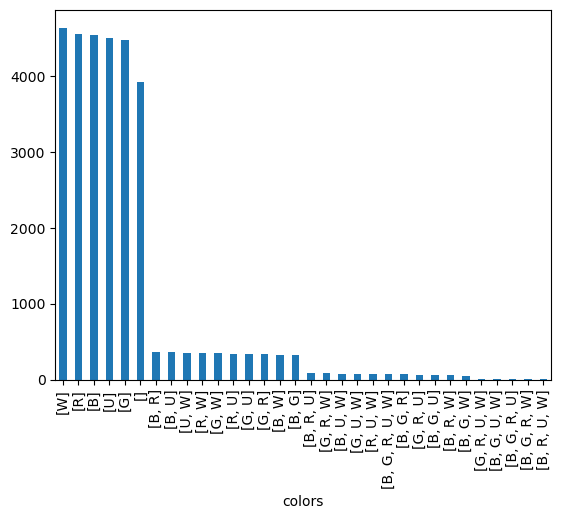

In [15]:
df_selected.colors.value_counts().plot(kind="bar")

We could transform this variable into 6 other variables: the 5 basic colors and 1 colorless. Let's do that.

In [16]:
color_map = {
    "W": "white",
    "U": "blue",
    "B": "black",
    "R": "red",
    "G": "green"
}

for code, name in color_map.items():
    df_selected[name] = df_selected["colors"].apply(
        lambda x: int(code in x) if isinstance(x, list) else 0
    )

has_colorless_mana = df_selected["mana_cost"].str.contains(r"\{C\}", na=False)

is_colorless_card = df_selected["colors"].isna() | \
    df_selected["colors"].apply(lambda x: isinstance(x, list) and len(x) == 0)

df_selected["colorless"] = (has_colorless_mana | is_colorless_card).astype(int)

Each card has also a "mana cost", which is the cost to cast these cards into play.

<Axes: xlabel='cmc'>

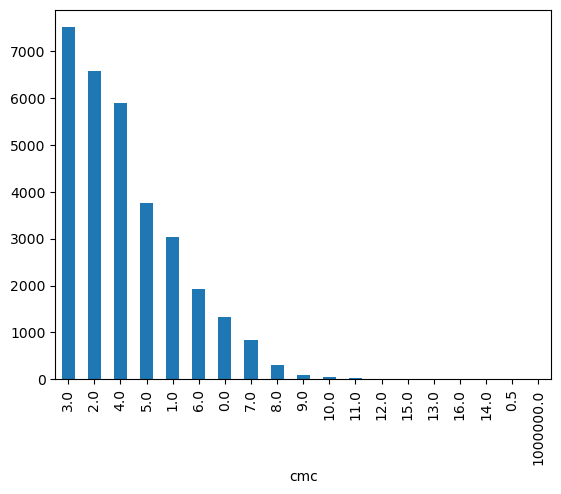

In [17]:
df_selected["cmc"].value_counts().plot(kind="bar")

There's a huge outlier with a card costing 1,000,000 manas to cast. We can use the median to avoid this issue when summarizing.

In [18]:
df_selected["cmc"].median()

np.float64(3.0)

In order to use the release date as variable, we need to transform the specific date into a variable.

In [19]:
current_year = pd.Timestamp.now().year

df_selected["card_age"] = current_year - pd.to_datetime(df_selected["released_at"]).dt.year

df_selected = df_selected.drop(columns = ["released_at"])

In [20]:
df_selected.dtypes

land            int64
creature        int64
artifact        int64
enchantment     int64
planeswalker    int64
                ...  
black           int64
red             int64
green           int64
colorless       int64
card_age        int32
Length: 120, dtype: object

We can create a variable to represent when a specific card is a mana producer, such as lands, artifacts, or creatures. A mana producer card gives the player an advantage in the game.

In [21]:
for c in ["W","U","B","R","G","C"]:
    df_selected[f"produces_{c}"] = df_selected["produced_mana"].apply(
        lambda x: int(c in x) if isinstance(x, list) else 0
    )

df_selected = df_selected.drop(columns=["produced_mana"])

Then create a dummy variable for rarity.

In [22]:
df_selected = pd.concat(
    [df_selected, pd.get_dummies(df_selected["rarity"], prefix="rarity")],
    axis=1
).drop(columns=["rarity"])

Also, we'll transform all False to 0 and True to 1, in order to use them for analysis.

In [23]:
df_selected = df_selected.replace({True: 1, False: 0})

In [24]:
df_selected.tail()

,land,creature,artifact,enchantment,planeswalker,battle,instant,sorcery,usd,usd_foil,...,produces_U,produces_B,produces_R,produces_G,produces_C,rarity_common,rarity_mythic,rarity_rare,rarity_special,rarity_uncommon
31358,0,0,0,0,0,0,1,0,0.13,0.29,...,0,0,0,0,0,1,0,0,0,0
31359,0,1,0,0,0,0,0,0,0.36,0.31,...,0,0,0,0,0,0,0,1,0,0
31360,0,1,1,0,0,0,0,0,6.25,6.16,...,0,0,0,0,0,0,1,0,0,0
31361,0,0,0,0,1,0,0,0,0.65,1.40,...,0,0,0,0,0,0,1,0,0,0
31362,0,1,0,0,0,0,0,0,0.49,NaN,...,0,0,0,0,0,1,0,0,0,0


## 3. Data Analysis

As a first exploration into the analysis, let's look at the mana costs of a normal card, the median USD cost, and number of cards with that mana cost.

In [25]:
colors = ["white","blue","black","green","red","colorless"]

df_selected["usd"] = pd.to_numeric(df_selected["usd"], errors="coerce")

result = (
    df_selected
    .groupby(colors)["usd"]
    .agg(median="median", n_cards="count")
    .reset_index()
    .sort_values("median", ascending=False)
)

result

,white,blue,black,green,red,colorless,median,n_cards
30,1,1,1,1,0,0,15.180,3
32,1,1,1,1,1,1,8.275,2
27,1,1,0,1,1,0,4.610,5
31,1,1,1,1,1,0,2.590,55
23,1,0,1,1,1,0,0.970,1
29,1,1,1,0,1,0,0.700,2
21,1,0,1,0,1,0,0.580,51
28,1,1,1,0,0,0,0.460,69
13,0,1,1,0,1,0,0.410,77
19,1,0,0,1,1,0,0.400,69


Do they differ too much from the foil version? We'll do the same analysis, but dropping NaN values, since some cards do not have a foil version.

In [26]:
df_selected["usd_foil"] = pd.to_numeric(df_selected["usd_foil"], errors="coerce")

result_foil = (
    df_selected
    .groupby(colors)["usd_foil"]
    .agg(median="median", n_cards="count")
    .reset_index()
    .sort_values("median", ascending=False)
    .dropna(subset=["median"])
)

result_foil

,white,blue,black,green,red,colorless,median,n_cards
30,1,1,1,1,0,0,15.520,3
23,1,0,1,1,1,0,13.015,2
27,1,1,0,1,1,0,9.270,5
15,0,1,1,1,1,0,7.040,1
29,1,1,1,0,1,0,4.490,2
31,1,1,1,1,1,0,3.210,36
22,1,0,1,1,0,0,0.790,39
28,1,1,1,0,0,0,0.700,57
21,1,0,1,0,1,0,0.625,50
0,0,0,0,0,0,1,0.570,3029


Looks like the foil cards tend to cost more than normal cards.

What's the relationship between card age and the card price?

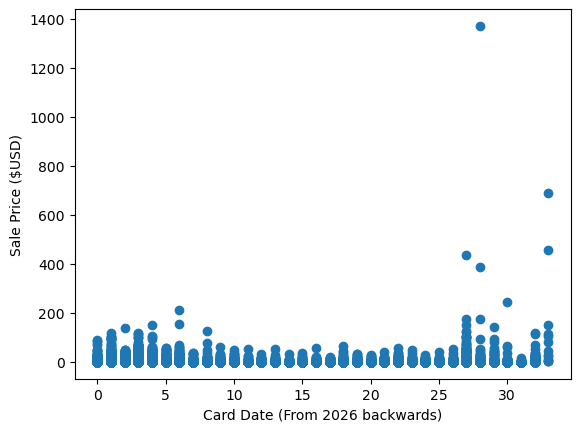

In [27]:
fig, ax = plt.subplots()
ax.scatter(x=df_selected["card_age"],
           y=df_selected["usd"])
ax.set_xlabel("Card Date (From 2026 backwards)")
ax.set_ylabel("Sale Price ($USD)");

<Axes: xlabel='Sale Price ($)', ylabel='Frequency'>

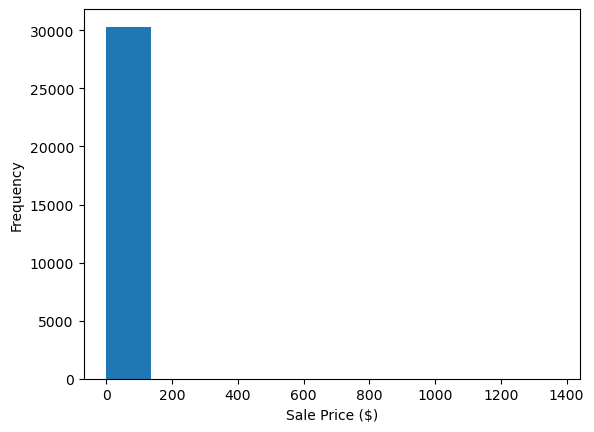

In [28]:
df_selected.usd.plot.hist(xlabel="Sale Price ($)")

How many cards have unproper NA's?

In [29]:
df_selected.isna().sum()[df_selected.isna().sum() > 0]

usd           1035
usd_foil      9303
defense      31362
mana_cost      487
colors         487
power        14125
toughness    14125
dtype: int64

Create a machine learning model and evaluate it.

In [30]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

np.random.seed(1104)

# Drop problematic columns
df_ml = df_selected.drop(columns=["usd_foil", "colors", "frame", "mana_cost"])

df_ml = df_ml.loc[:, ~df_ml.columns.duplicated()]

# Convert to numeric
df_ml = df_ml.apply(pd.to_numeric, errors="coerce")

# Drop missing target
df_ml = df_ml.dropna(subset=["usd"])

# Fill valid columns with 0
cols_to_fill = [
    "defense","power", "toughness", "vintage", "duel", "oldschool"
]

df_ml[cols_to_fill] = df_ml[cols_to_fill].fillna(0)

# Number of colors of each card
color_cols = ["white","blue","black","red","green"]
df_ml["n_colors"] = df_ml[color_cols].sum(axis=1)

# Split dataset into predictor and predicted
X = df_ml.drop("usd", axis=1)
y = np.log1p(df_ml["usd"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1104
)

# Model
model = Ridge()
model.fit(X_train, y_train)

# Make predictions
y_preds = model.predict(X_test)

# Evaluate the model
print("Regression model metrics on the test set:")
print(f"R^2: {r2_score(y_test, y_preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_preds):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_preds):.2f}")

Regression model metrics on the test set:
R^2: 0.35
MAE: 0.36
RMSE: 0.59


The model explains about 35% of the variance in card prices, with moderate prediction error. Moderate performance, but clearly missing important patterns. ≈ 43% average error in price: predictions are often noticeably off in practical terms. This model performs worse probably beccause price is a linear combination of features, but we have nonlinear relationships and feature interactions.

In [31]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=5,
    random_state=1104,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
118,rarity_common,0.228594
119,rarity_mythic,0.132389
22,duel,0.113288
122,rarity_uncommon,0.108164
18,vintage,0.091667
25,predh,0.053683
15,modern,0.034231
16,legacy,0.018041
24,premodern,0.017679
19,commander,0.015839


Few features are looking important. Let's try to run an ElasticNet as a next step to see if model performance gets better.

In [32]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Reproducibility
np.random.seed(1104)

# Split features and target
X = df_ml.drop("usd", axis=1)
y = np.log1p(df_ml["usd"])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1104
)

# Pipeline: scaling + model
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=5000, random_state=1104))
])

# Hyperparameter space
param_grid = {
    "model__alpha": np.logspace(-3, 1, 20),      # 0.001 → 10
    "model__l1_ratio": np.linspace(0.1, 0.9, 10) # Ridge ↔ Lasso mix
}

# Random search
rs_model = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=100,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=1104
)

# Fit
rs_model.fit(X_train, y_train)

# Best params
print("Best params:", rs_model.best_params_)

# Predictions
y_preds = rs_model.predict(X_test)

# Evaluation
print("\nElasticNet Performance:")
print(f"R^2: {r2_score(y_test, y_preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_preds)):.2f}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best params: {'model__l1_ratio': np.float64(0.7222222222222222), 'model__alpha': np.float64(0.029763514416313176)}

ElasticNet Performance:
R^2: 0.31
MAE: 0.36
RMSE: 0.61


The Elastic Net model, optimized via randomized search with cross-validation, achieved modest predictive performance, explaining approximately 31% of the variance in card prices (R² = 0.31). The model selected a relatively low regularization strength (alpha ≈ 0.03) with a stronger Lasso component (l1_ratio ≈ 0.72), indicating a preference for feature selection alongside coefficient shrinkage. Despite this tuning, error metrics (MAE = 0.36; RMSE = 0.61) suggest that predictions remain imprecise, with notable deviations from actual values. Overall, the results indicate that while Elastic Net captures some general linear relationships in the data, it struggles to model the complex and nonlinear dynamics underlying card pricing. Thus, we need to model non-linearities with Random Forest.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

np.random.seed(1104)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1104
)

# Model
model = RandomForestRegressor(n_estimators=200,
                              min_samples_split=4,
                              random_state=1104,
                              max_depth=20,
                              min_samples_leaf=2
                              )
model.fit(X_train, y_train)

# Make predictions
y_preds = model.predict(X_test)

# Evaluate the model
print("Random Forrest Regressor Performance:")
print(f"R^2: {r2_score(y_test, y_preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_preds):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_preds):.2f}")

Random Forrest Regressor Performance:
R^2: 0.47
MAE: 0.30
RMSE: 0.53


The Random Forest regression model demonstrated moderate predictive performance on the test set, achieving an 
𝑅² of 0.47. This indicates that the model explains approximately 47% of the variance in card prices, suggesting that it captures a substantial portion of the underlying pricing structure, though there remains unexplained variability.

The model’s mean absolute error (MAE) was 0.30 in log-transformed units. Interpreted in the original price scale, this corresponds to an average prediction error of approximately ±35%, indicating a reasonable level of accuracy given the inherent variability of card prices.

The root mean squared error (RMSE) of 0.54 is notably higher than the MAE, suggesting the presence of larger prediction errors for some cards, likely corresponding to high-value or atypical cards. This pattern indicates that while the model performs well on typical cases, it is less precise for extreme or outlier prices.

Can we improve even more the model performance? Let's try another ensemble option.

In [34]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

np.random.seed(1104)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1104
)

# Model
model = HistGradientBoostingRegressor(max_iter=100, random_state=1104)

model.fit(X_train, y_train)

# Make predictions
y_preds = model.predict(X_test)

# Evaluate the model
print("Regression model metrics on the test set:")
print(f"R^2: {r2_score(y_test, y_preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_preds):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_preds):.2f}")

Regression model metrics on the test set:
R^2: 0.51
MAE: 0.30
RMSE: 0.51


| Model                    | R²       | MAE      | RMSE     |
| ------------------------ | -------- | -------- | -------- |
| Ridge                    | 0.35     | 0.36     | 0.59     |
| ElasticNet               | 0.31     | 0.36     | 0.61     |
| Random Forest            | 0.47     | 0.30     | 0.53     |
| **HistGradientBoosting** | **0.51** | **0.30** | **0.51** |


The HistGradientBoosting model achieved the best performance among all tested models, explaining approximately 50% of the variance in card prices (R² = 0.51). Error metrics (MAE = 0.30; RMSE = 0.51) indicate improved predictive accuracy and reduced large prediction errors compared to previous models.

Relative to Random Forest, the gradient boosting approach yielded modest but consistent gains, suggesting a better ability to capture complex nonlinear relationships and interactions between features.

These results reinforce the importance of flexible, nonlinear modeling techniques for capturing the multifaceted drivers of Magic: The Gathering card prices. Let's try to improve even more with the exploration of the tuning parameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

param_grid = {
    "max_iter": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization": [0.0, 0.1, 1.0]
}

rs_model = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=1104),
    param_distributions=param_grid,
    n_iter=50,            
    cv=3,                 
    verbose=3,
    n_jobs=-1,
    random_state=1104
)

rs_model.fit(X_train, y_train)

print("Best params:", rs_model.best_params_)

y_preds = rs_model.predict(X_test)

print("Tuned model performance:")
print(f"R^2: {r2_score(y_test, y_preds):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_preds)):.2f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits


Hyperparameter tuning of the HistGradientBoosting model resulted in a minor  improvement in predictive performance, increasing the explained variance from 0.50 to 0.51. The optimized model achieved lower prediction error (MAE = 0.29) while maintaining stable RMSE, indicating improved overall accuracy without reducing large prediction deviations.

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model, X_test, y_test,
    n_repeats=5,
    random_state=1104,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head(20)

The permutation importance analysis revealed that card rarity is the strongest predictor of price, with mythic and rare cards showing substantially higher importance than all other variables. This indicates that scarcity is the primary driver of market value.

In addition, card age emerged as a major factor, suggesting that older cards tend to be more valuable, likely due to collectibility and reduced supply over time.

Variables related to format legality, such as Pioneer, Premodern, and Modern, also contributed meaningfully to predictions. This highlights that playability in popular formats increases card demand and price.

Secondary effects were observed for:

- Card characteristics, such as mana cost (cmc) and number of colors (n_colors)
- Card type, particularly lands
- Gameplay mechanics extracted from text, such as “add” (mana generation), “control”, and “opponent”

These results suggest that while intrinsic gameplay features and mechanics matter, they play a smaller role compared to rarity, age, and format legality.

Overall, the model indicates that economic factors (rarity and age) and playability (format legality) dominate price formation, while card abilities and design features provide incremental predictive value.

In [ ]:
importance_df.head(20).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,6)
)

In [ ]:
import shap
import numpy as np

# Create explicit random generator
rng = np.random.default_rng(1104)

# Sample data
X_sample = X_test.sample(5000, random_state=1104)

# Use TreeExplainer explicitly
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

# Plot with RNG
shap.summary_plot(shap_values, X_sample, rng=rng)

The SHAP analysis in a sample of 5000 cards indicates that card rarity is the strongest determinant of price, with mythic and rare cards significantly increasing predicted values. Card age also plays a major role, with older cards being consistently associated with higher prices.

Format legality variables, such as Pioneer and Modern, further contribute negatively, highlighting the importance of playability.

In contrast, common and uncommon rarity has a negative impact on price, reflecting expected scarcity dynamics.

Gameplay-related features extracted from card text (e.g., “control”, “add”, “opponent”) show smaller but consistent effects, suggesting that specific mechanics contribute incrementally to card value.

Overall, the results indicate that economic factors (rarity and age) and playability dominate price formation, while intrinsic card characteristics play a secondary role.

## 4. Conclusion

This study aimed to predict ***Magic: The Gathering*** card prices using a machine learning approach based on card characteristics, gameplay attributes, and textual features. A HistGradientBoosting, optimized via RandomizedSearchCV, achieved moderate predictive performance, explaining approximately 52% of the variance in card prices (R² = 0.52). Error metrics (MAE = 0.29; RMSE = 0.51, in log-transformed units) indicate that while the model captures general pricing patterns, substantial variability remains unexplained.

Feature importance analysis reveals that economic and structural variables dominate price formation. In particular, rarity (especially mythic and rare) emerged as the strongest predictor, followed by card age, reinforcing the importance of scarcity and collectibility. Additionally, format legality variables (e.g., Pioneer, Modern) contributed meaningfully, indicating that competitive playability is a key driver of card value.

In contrast, intrinsic gameplay characteristics, such as power, mana cost (CMC), and text-derived mechanics, had comparatively smaller effects. This suggests that while card abilities and mechanics influence price, they play a secondary role relative to broader market factors.

Overall, the findings indicate that ***Magic: The Gathering*** card prices are primarily shaped by a combination of scarcity (rarity), temporal factors (age), and playability (format legality), with card-specific mechanics contributing incrementally. The moderate performance of the model also highlights the presence of unobserved factors, such as meta-game dynamics, reprint expectations, and collector demand, which are not fully captured in the current feature set.

Future work could improve predictive accuracy by incorporating market dynamics, temporal price trends, and external demand indicators, as well as exploring more advanced models such as gradient boosting methods.